In [831]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler




In [832]:
data=pd.read_csv(r"Z:\Internship\DataSet\fifa21 raw data v2.csv")
data.head()
data_before=data

C:\Users\HP\AppData\Local\Temp\ipykernel_5956\2952195407.py:1: DtypeWarning: Columns (76) have mixed types. Specify dtype option on import or set low_memory=False.
  data=pd.read_csv(r"Z:\Internship\DataSet\fifa21 raw data v2.csv")


In [833]:
print(data.isnull().sum())

ID              0
Name            0
LongName        0
photoUrl        0
playerUrl       0
             ... 
PAS             0
DRI             0
DEF             0
PHY             0
Hits         2595
Length: 77, dtype: int64


In [834]:
data = data.drop(["LongName","Loan Date End"],axis=1)

In [835]:
data['photoUrl']=data['photoUrl'].str.strip()
data['playerUrl']=data['playerUrl'].str.strip()


In [836]:
print(data['Hits'].dtype)
data['Hits']=pd.to_numeric(data['Hits'],errors='coerce')
data['Hits']=data['Hits'].fillna(data['Hits'].median())
print(data.isnull().sum())

object
ID             0
Name           0
photoUrl       0
playerUrl      0
Nationality    0
              ..
PAS            0
DRI            0
DEF            0
PHY            0
Hits           0
Length: 75, dtype: int64


In [837]:
data['Joined'] = pd.to_datetime(data['Joined'], errors='coerce')

In [838]:

# data['Value']=pd.to_numeric(data['Value'])
# print(data['Value'].dtype)
# print(data['Value'].isnull().sum())

In [839]:
data['Value']=data['Value'].str.replace('€','')
data['Value']=data['Value'].str.replace('M','000000')
data['Value']=data['Value'].str.replace('K','000')
#data['Value']=data['Value'].fillna(data['Value'].median())
print(data['Value'])



0        103.5000000
1           63000000
2          120000000
3          129000000
4          132000000
            ...     
18974         100000
18975         130000
18976         120000
18977         100000
18978         100000
Name: Value, Length: 18979, dtype: object


In [840]:
data['Value']=data['Value'].astype(float)
print(data['Value'])


0              103.5
1         63000000.0
2        120000000.0
3        129000000.0
4        132000000.0
            ...     
18974       100000.0
18975       130000.0
18976       120000.0
18977       100000.0
18978       100000.0
Name: Value, Length: 18979, dtype: float64


In [841]:

data['Wage']=data['Wage'].str.replace('€','')
data['Wage']=data['Wage'].str.replace('K','000').astype(float)
print(data['Wage'])


0        560000.0
1        220000.0
2        125000.0
3        370000.0
4        270000.0
           ...   
18974      1000.0
18975       500.0
18976       500.0
18977      2000.0
18978      1000.0
Name: Wage, Length: 18979, dtype: float64


In [842]:

data['Release Clause']=data['Release Clause'].str.replace('€','')
data['Release Clause']=data['Release Clause'].str.replace('M','000000')
data['Release Clause']=data['Release Clause'].str.replace('K','000').astype(float)
print(data['Release Clause'])


0              138.4
1               75.9
2              159.4
3        161000000.0
4              166.5
            ...     
18974        70000.0
18975       165000.0
18976       131000.0
18977        88000.0
18978        79000.0
Name: Release Clause, Length: 18979, dtype: float64


In [843]:
data['Value']=data['Value'].astype(float)
print(data['Value'])


0              103.5
1         63000000.0
2        120000000.0
3        129000000.0
4        132000000.0
            ...     
18974       100000.0
18975       130000.0
18976       120000.0
18977       100000.0
18978       100000.0
Name: Value, Length: 18979, dtype: float64


In [844]:
data['Weight']=data['Weight'].str.replace('kg','')
data['Weight']=data['Weight'].str.replace('lbs','').astype(float)
print(data['Weight'])
print(data['Weight'].dtype)


0        72.0
1        83.0
2        87.0
3        70.0
4        68.0
         ... 
18974    66.0
18975    65.0
18976    74.0
18977    69.0
18978    75.0
Name: Weight, Length: 18979, dtype: float64
float64


In [845]:
# data['Height']=data['Height'].astype(float)
# print(data['Height'].dtype)

In [846]:
data['W/F']=data['W/F'].str.replace(' ★','').astype(float)
data['SM']=data['SM'].str.replace('★','').astype(float)
data['IR']=data['IR'].str.replace('★','').astype(float)
print(data['W/F'].dtype)
print(data['SM'].dtype)
print(data['IR'].dtype)


float64
float64
float64


In [847]:
data['Joined']=pd.to_datetime(data['Joined'])
year=data[2026-data['Joined'].dt.year>10]
print(year['Name'])

0                 L. Messi
2                 J. Oblak
3             K. De Bruyne
5           R. Lewandowski
9            M. ter Stegen
               ...        
18390           J. Stevens
18416        B. Al Bahrani
18781            S. Callan
18915    Chen-Zeng Tailang
18917            Gao Xiang
Name: Name, Length: 1658, dtype: object


In [848]:
for col in data.columns:
    if data[col].dtype == 'object':
        data[col].replace('/n','',regex=False).str.strip()

In [849]:
# value=np.percentile(data['Wage'],0.30)
# underpaid=data[data['Wage']<value]
# print(underpaid)
# q1=data['Wage'].quantile(0.75)
# q2=data['Wage'].quantile(0.50)
# q3=data['Wage'].quantile(0.25)
# avg=(q1+q2+q3)/3
# for i in data['Wage']:
#     if i < avg:
#         print('underpaid')

# for i in data.columns:
#     mean=data[i].mean()
#     print(mean)

# for i in data['Wage']:
#     if mean < 0.35:
#         print('underpaid')






In [850]:
mean_data=data['Wage'].mean()
print(mean_data)

mean_data=mean_data*0.35
d=data[data['Wage']<mean_data]    
print(d['Name'])    


9092.0622793614
289      Welington Dano
292      Juiano Mestres
346             Ismaily
354              Marlos
358              Taison
              ...      
18974            Xia Ao
18975          B. Hough
18976       R. McKinley
18977      Wang Zhen'ao
18978         Zhou Xiao
Name: Name, Length: 10563, dtype: object


In [851]:
data.drop_duplicates(inplace=True)


In [852]:
#Normalizaton

df_numerical_features = data.select_dtypes(include=['float64','int64']).columns
print(df_numerical_features)


Index(['ID', 'Age', '↓OVA', 'POT', 'Weight', 'BOV', 'Value', 'Wage',
       'Release Clause', 'Attacking', 'Crossing', 'Finishing',
       'Heading Accuracy', 'Short Passing', 'Volleys', 'Skill', 'Dribbling',
       'Curve', 'FK Accuracy', 'Long Passing', 'Ball Control', 'Movement',
       'Acceleration', 'Sprint Speed', 'Agility', 'Reactions', 'Balance',
       'Power', 'Shot Power', 'Jumping', 'Stamina', 'Strength', 'Long Shots',
       'Mentality', 'Aggression', 'Interceptions', 'Positioning', 'Vision',
       'Penalties', 'Composure', 'Defending', 'Marking', 'Standing Tackle',
       'Sliding Tackle', 'Goalkeeping', 'GK Diving', 'GK Handling',
       'GK Kicking', 'GK Positioning', 'GK Reflexes', 'Total Stats',
       'Base Stats', 'W/F', 'SM', 'IR', 'PAC', 'SHO', 'PAS', 'DRI', 'DEF',
       'PHY', 'Hits'],
      dtype='object')


In [853]:
d1=data['Joined']
d1.head()


0   2004-07-01
1   2018-07-10
2   2014-07-16
3   2015-08-30
4   2017-08-03
Name: Joined, dtype: datetime64[ns]

In [854]:
data['Joined']=data['Joined'].astype(object)

In [855]:
for i in df_numerical_features:
    q1=data[i].quantile(0.75)
    q3=data[i].quantile(0.25)
    iqr=q1-q3
    upper_limit = data[i].quantile(0.99)
    lower_limit = data[i].quantile(0.01)
    data[i] = data[i].clip(lower=lower_limit, upper=upper_limit)
    print(data[i])

0        158023.00
1        148394.64
2        200389.00
3        192985.00
4        190871.00
           ...    
18974    247223.00
18975    258760.00
18976    252757.00
18977    243790.00
18978    252520.00
Name: ID, Length: 18979, dtype: float64
0        33.0
1        35.0
2        27.0
3        29.0
4        28.0
         ... 
18974    21.0
18975    17.0
18976    18.0
18977    20.0
18978    21.0
Name: Age, Length: 18979, dtype: float64
0        83
1        83
2        83
3        83
4        83
         ..
18974    50
18975    50
18976    50
18977    50
18978    50
Name: ↓OVA, Length: 18979, dtype: int64
0        86
1        86
2        86
3        86
4        86
         ..
18974    58
18975    67
18976    65
18977    58
18978    58
Name: POT, Length: 18979, dtype: int64
0        72.0
1        83.0
2        87.0
3        70.0
4        68.0
         ... 
18974    66.0
18975    65.0
18976    74.0
18977    69.0
18978    75.0
Name: Weight, Length: 18979, dtype: float64
0        83
1  

In [856]:
scaler = MinMaxScaler()
for i in df_numerical_features:
    data[i]=scaler.fit_transform(data[[i]])

# normalized_data = scaler.fit_transform(df_numerical_features)
# print("Normalized Data (Min-Max Scaling):")
# print(normalized_data)

In [857]:
data.head()

,ID,Name,photoUrl,playerUrl,Nationality,Age,↓OVA,POT,Club,Contract,...,A/W,D/W,IR,PAC,SHO,PAS,DRI,DEF,PHY,Hits
0,0.087136,L. Messi,https://cdn.sofifa.com/players/158/023/21_60.png,http://sofifa.com/player/158023/lionel-messi/2...,Argentina,0.832466,1.0,1.0,\n\n\n\nFC Barcelona,2004 ~ 2021,...,Medium,Low,1.0,0.907783,1.0,1.000000,1.0,0.327869,0.581395,1.000000
1,0.000000,Cristiano Ronaldo,https://cdn.sofifa.com/players/020/801/21_60.png,http://sofifa.com/player/20801/c-ronaldo-dos-s...,Portugal,0.936524,1.0,1.0,\n\n\n\nJuventus,2018 ~ 2022,...,High,Low,1.0,0.981557,1.0,1.000000,1.0,0.278689,0.860465,1.000000
2,0.470547,J. Oblak,https://cdn.sofifa.com/players/200/389/21_60.png,http://sofifa.com/player/200389/jan-oblak/210006/,Slovenia,0.520291,1.0,1.0,\n\n\n\nAtlético Madrid,2014 ~ 2023,...,Medium,Medium,1.0,0.944670,1.0,0.957447,1.0,0.557377,1.000000,0.510274
3,0.403542,K. De Bruyne,https://cdn.sofifa.com/players/192/985/21_60.png,http://sofifa.com/player/192985/kevin-de-bruyn...,Belgium,0.624350,1.0,1.0,\n\n\n\nManchester City,2015 ~ 2023,...,High,High,1.0,0.741793,1.0,1.000000,1.0,0.754098,0.883721,0.705479
4,0.384410,Neymar Jr,https://cdn.sofifa.com/players/190/871/21_60.png,http://sofifa.com/player/190871/neymar-da-silv...,Brazil,0.572320,1.0,1.0,\n\n\n\nParis Saint-Germain,2017 ~ 2022,...,High,Medium,1.0,1.000000,1.0,1.000000,1.0,0.295082,0.441860,1.000000


In [858]:
g = data.groupby('Preferred Foot') 
min_size = g.size().min()
data = g.apply(lambda x: x.sample(min_size)).reset_index(drop=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_5956\3005082709.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = g.apply(lambda x: x.sample(min_size)).reset_index(drop=True)


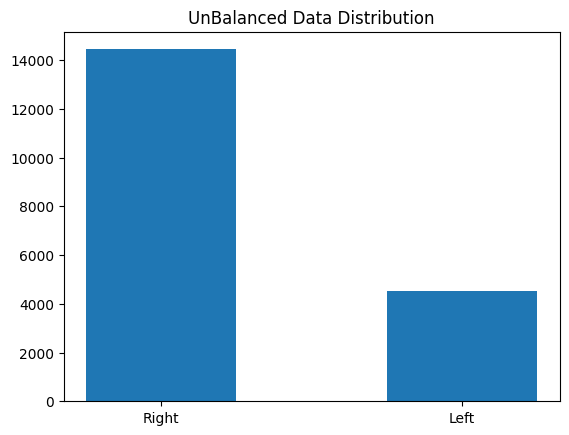

In [859]:
data_plot=data_before['Preferred Foot'].value_counts()
plt.bar(data_plot.index, data_plot.values, width=0.5)
plt.title("UnBalanced Data Distribution")
plt.show()

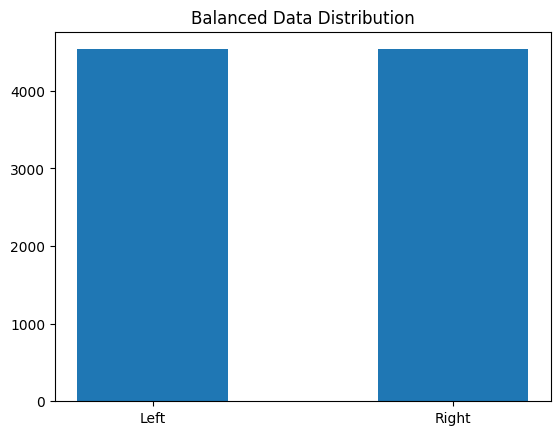

In [860]:
data_plot=data['Preferred Foot'].value_counts()
plt.bar(data_plot.index, data_plot.values, width=0.5)
plt.title("Balanced Data Distribution")
plt.show()